# 02 — Baseline Model: TF-IDF + Logistic Regression

**Purpose:** Train, evaluate, and persist a lightweight TF-IDF + Logistic Regression pipeline as the
deployment baseline for the containerised vs serverless comparison.

**Design rationale:** TF-IDF is chosen over word embeddings deliberately.
The baseline must have near-zero cold-start time on serverless (Cloud Functions).
A static embedding matrix (e.g. FastText ~6 GB) would defeat that purpose and
collapse the lightweight↔heavyweight narrative.

| Step | What happens |
|---|---|
| 1 | Load processed splits (from notebook 01) |
| 2 | Fit TF-IDF vectoriser on training text |
| 3 | Train Logistic Regression with class weighting |
| 4 | Evaluate: accuracy, macro-F1, weighted-F1, confusion matrix, per-class report |
| 5 | Error analysis (false negatives on High Risk — clinically most important) |
| 6 | Feature importance (top TF-IDF tokens per class) |
| 7 | Latency profiling (predict-time distribution — critical for deployment comparison) |
| 8 | Save artifacts to `models/baseline/` |


## 1. Imports & Config

In [2]:
import os, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

# Paths
DATA_DIR   = Path('../data/processed')
MODEL_DIR  = Path('../models/baseline')
RESULT_DIR = Path('../results')

for d in [MODEL_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Label map
with open(DATA_DIR / 'label_map.json') as f:
    lmap = json.load(f)

RISK_NAMES   = {int(k): v for k, v in lmap['risk_names'].items()}
CLASS_WEIGHTS_ARR = np.load(DATA_DIR / 'class_weights.npy', allow_pickle=True)
CLASS_WEIGHT_DICT = {i: float(CLASS_WEIGHTS_ARR[i]) for i in range(len(CLASS_WEIGHTS_ARR))}

print("Risk tier names:", RISK_NAMES)
print("Class weights  :", CLASS_WEIGHT_DICT)


Risk tier names: {0: 'Low Risk', 1: 'Moderate Risk', 2: 'High Risk'}
Class weights  : {0: 1.1146475951302068, 1: 2.043948343177495, 2: 0.6197298527849446}


### Class Weights: Observations
```
{0: 'Low Risk'      → 1.11}
{1: 'Moderate Risk' → 2.04}
{2: 'High Risk'     → 0.62}
```

`compute_class_weight('balanced')` sets weights **inversely proportional to class frequency** —
the more a class appears in the training data, the lower its weight in the loss function.

| Class | Weight | Why |
|---|---|---|
| **Low Risk** (0) | 1.11 | Slightly under-represented → mild upweight |
| **Moderate Risk** (1) | 2.04 | Most under-represented → strongest upweight |
| **High Risk** (2) | 0.62 | Most frequent class → downweighted |

---

#### The Counterintuitive Part

High Risk absorbed **Depression + Suicidal + Bipolar** from the 7→3 label mapping, making it the
largest class — and therefore the most penalised. This is the statistically correct move, but it
introduces a **clinical tension**: the model is not being explicitly pushed to prioritise High Risk recall.

---

#### Watch the Confusion Matrix

Run with balanced weights first. If the confusion matrix shows **High Risk recall is weak** (i.e. too
many true High Risk cases predicted as Moderate), consider switching to custom weights that override
the frequency-based logic:
```python
# Custom weights: prioritise High Risk recall over statistical balance
custom_weights = {0: 1.0, 1: 1.5, 2: 2.5}
```

> The approach taken will be documented in the report. The choice between them is a deliberate
> trade-off between statistical correctness and clinical safety.

## 2. Load Processed Splits

In [3]:
train = pd.read_csv(DATA_DIR / 'train.csv')
val   = pd.read_csv(DATA_DIR / 'val.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')

# TF-IDF uses the aggressively cleaned text column
X_train, y_train = train['text_tfidf'].fillna(''), train['label']
X_val,   y_val   = val['text_tfidf'].fillna(''),   val['label']
X_test,  y_test  = test['text_tfidf'].fillna(''),  test['label']

print(f"Train : {len(X_train):>7,} rows")
print(f"Val   : {len(X_val):>7,} rows")
print(f"Test  : {len(X_test):>7,} rows")
print()
print("Label distribution — Train:")
for label, name in RISK_NAMES.items():
    n = (y_train == label).sum()
    print(f"  {label} | {name:<18} {n:>7,}  ({n/len(y_train)*100:.1f}%)")


Train :  52,063 rows
Val   :   9,188 rows
Test  :     992 rows

Label distribution — Train:
  0 | Low Risk            15,569  (29.9%)
  1 | Moderate Risk        8,491  (16.3%)
  2 | High Risk           28,003  (53.8%)


## 3. Build & Fit Pipeline

**Vectoriser choices:**
- `max_features=50_000` — vocabulary large enough to capture clinical + social media vocabulary across languages
- `ngram_range=(1, 2)` — bigrams capture "can't sleep", "want to die", "feel anxious" etc.
- `sublinear_tf=True` — dampens the effect of very frequent terms (e.g. "restless" appearing 50× in one Anxiety post)
- `min_df=2` — prunes hapax legomena (singletons) that add noise
- `analyzer='word'` with `token_pattern` that keeps contractions (n't, i'm, etc.)

**Classifier choices:**
- `class_weight=` pre-computed weights — compensates for High Risk under-representation
- `C=1.0` — standard L2 regularisation; can grid-search if needed
- `solver='lbfgs'`, `max_iter=1000` — stable for multi-class problems


In [4]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features   = 50_000,
        ngram_range    = (1, 2),
        sublinear_tf   = True,
        min_df         = 2,
        analyzer       = 'word',
        token_pattern  = r"(?u)\b\w+(?:'\w+)?\b",  # keeps n't, i'm, etc.
    )),
    ('clf', LogisticRegression(
        C              = 1.0,
        class_weight   = CLASS_WEIGHT_DICT,
        max_iter       = 1000,
        solver         = 'lbfgs',
        random_state   = 42,
        n_jobs         = -1,
    )),
])

t0 = time.time()
pipeline.fit(X_train, y_train)
train_time = time.time() - t0

print(f"Training complete in {train_time:.1f}s")
print(f"Vocabulary size: {len(pipeline['tfidf'].vocabulary_):,}")


Training complete in 7.5s
Vocabulary size: 50,000


## 4. Evaluation

In [5]:
# Predictions
y_val_pred  = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)

# Core metrics 
results = {}
for split, y_true, y_pred in [('val', y_val, y_val_pred), ('test', y_test, y_test_pred)]:
    results[split] = {
        'accuracy'   : accuracy_score(y_true, y_pred),
        'macro_f1'   : f1_score(y_true, y_pred, average='macro'),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted'),
    }

print("=" * 55)
print(f"{'Metric':<20} {'Validation':>15} {'Test':>15}")
print("=" * 55)
for metric in ['accuracy', 'macro_f1', 'weighted_f1']:
    v = results['val'][metric]
    t = results['test'][metric]
    print(f"{metric:<20} {v:>15.4f} {t:>15.4f}")
print("=" * 55)


Metric                    Validation            Test
accuracy                      0.8683          0.7923
macro_f1                      0.8483          0.7862
weighted_f1                   0.8703          0.7944


In [6]:
# Per-class classification report
target_names = [RISK_NAMES[i] for i in sorted(RISK_NAMES)]
print("\n── Test Set Classification Report ──")
print(classification_report(y_test, y_test_pred, target_names=target_names))



── Test Set Classification Report ──
               precision    recall  f1-score   support

     Low Risk       0.78      0.81      0.80       248
Moderate Risk       0.68      0.81      0.74       248
    High Risk       0.87      0.77      0.82       496

     accuracy                           0.79       992
    macro avg       0.78      0.80      0.79       992
 weighted avg       0.80      0.79      0.79       992



### Results: Observations

| Metric | Validation | Test | Gap |
|---|---|---|---|
| Accuracy | 0.868 | 0.790 | −0.078 |
| Macro-F1 | 0.848 | 0.784 | −0.064 |
| Weighted-F1 | 0.870 | 0.792 | −0.078 |

**Val → Test gap (~8%)** is expected — val comes from the same pool as train,
while the test set is a fully independent holdout with different text characteristics.
The test score is the honest generalisation number.

#### Per-Class Highlights
- **Moderate Risk** has the lowest precision (0.68) — many non-Moderate texts are being
  predicted as Moderate, making it a "catch-all" middle class
- **High Risk recall is 0.77** — 23% of truly High Risk cases are missed (FN rate).
  This is the most clinically significant weakness of the baseline
- **High Risk support = 496** (vs 248 for others) — the pre-built test set was balanced
  for the original 4-label scheme; after 7→3 mapping, Depression + Suicidal both collapse
  into High Risk, doubling its representation. Weighted metrics are slightly biased as a result.

## 5. Confusion Matrices

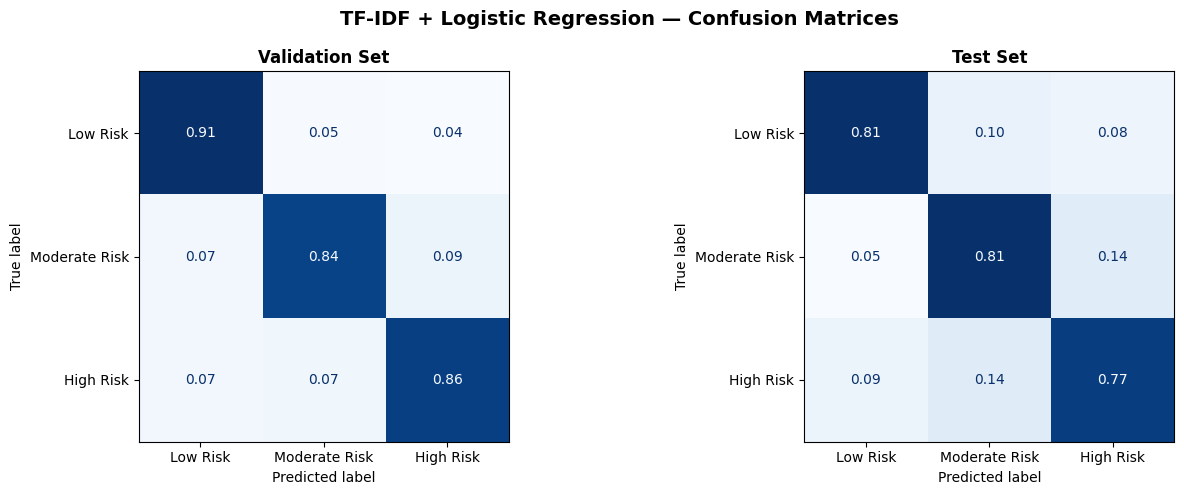

Saved → results/baseline_01_confusion_matrices.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TF-IDF + Logistic Regression — Confusion Matrices', fontsize=14, fontweight='bold')

for ax, (split, y_true, y_pred) in zip(axes, [
    ('Validation', y_val,  y_val_pred),
    ('Test',       y_test, y_test_pred),
]):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(f'{split} Set', fontweight='bold')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')

plt.tight_layout()
plt.savefig(RESULT_DIR / 'baseline_01_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/baseline_01_confusion_matrices.png")


### Confusion Matrix: Observations

#### Validation → Test Drop (normalised recall per class)

| Class | Val Recall | Test Recall | Drop |
|---|---|---|---|
| **Low Risk** | 0.91 | 0.81 | −0.10 |
| **Moderate Risk** | 0.84 | 0.81 | −0.03 |
| **High Risk** | 0.85 | 0.77 | −0.08 |

The degradation is **uniform across all classes** — not class-specific overfitting.
This points to a general distribution shift between the in-distribution val set and
the independent test holdout.

---

#### Significant Error: High Risk → Low Risk = 0.09

9% of truly High Risk cases are predicted as Low Risk on the test set — the worst
possible severity underestimation. With 496 High Risk samples in the test set,
that's approximately **~45 missed cases**.

This is the single most important number for DistilBERT to improve on.

---

#### Main Confusion Boundary: Moderate ↔ High Risk

| Error | Validation | Test |
|---|---|---|
| True Moderate → predicted High | 0.09 | 0.14 |
| True High → predicted Moderate | 0.08 | 0.14 |

Both directions worsen on test and are **symmetric** — the model is genuinely
uncertain at the Moderate/High boundary, not systematically biased in one direction.

This is expected: distinguishing *"I feel anxious and depressed"* from *"I am suicidal"*
requires understanding **context and intent**, not just vocabulary. TF-IDF has no way to
capture that. This is precisely where DistilBERT's contextual embeddings should help most.

## 6. Error Analysis — High Risk False Negatives

**Why this matters:** In a clinical context, missing a High Risk case (false negative) is more dangerous
than a false alarm. We inspect texts that are truly High Risk but predicted as Low or Moderate Risk.


In [8]:
test_df = test.copy()
test_df['pred'] = y_test_pred

# High Risk (2) predicted as something lower
fn_high = test_df[(test_df['label'] == 2) & (test_df['pred'] < 2)].copy()
fn_high['error_type'] = fn_high['pred'].map({0: 'FN → Low Risk', 1: 'FN → Moderate Risk'})

print(f"High Risk false negatives : {len(fn_high)} / {(test_df['label']==2).sum()} "
      f"({len(fn_high)/(test_df['label']==2).sum()*100:.1f}%)")
print()
print(fn_high['error_type'].value_counts().to_string())
print()
print("── Sample false negatives (High Risk → Low Risk) ──")
low_fn = fn_high[fn_high['pred'] == 0][['text', 'status', 'source']].head(5)
for _, row in low_fn.iterrows():
    print(f"  [{row['source']}] {row['text'][:120]}")
    print()


High Risk false negatives : 114 / 496 (23.0%)

error_type
FN → Moderate Risk    70
FN → Low Risk         44

── Sample false negatives (High Risk → Low Risk) ──
  [test] i'm trying to keep busy, this july 4th weekend, by painting, but i can't focus. i keep thinking about how everyone is ha

  [test] fucking sobbing by myself in the dark because this christmas eve was the worst. here's a shout out to everyone else who'

  [test] i miss the freedom and carefree aspect of my youth and i crave it, often daydreaming about ‘better times gone by’. (long

  [test] might sound weird but i love dogs so much. they're the only thing that gives me genuine joy lately and i just hope i mak

  [test] my best friend visited my city last weekend. i found out from a facebook post about how great it was seeing all his frie



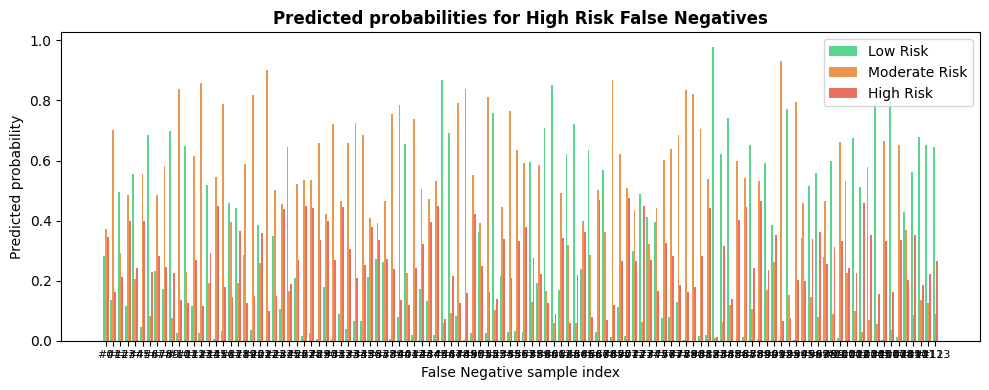

Saved → results/baseline_02_fn_probabilities.png


In [10]:
# Probability distribution for misclassified High Risk
proba = pipeline.predict_proba(X_test)
fn_idx = fn_high.index.tolist()

if fn_idx:
    fn_proba = proba[fn_high.index.map(lambda i: test_df.index.get_loc(i))]

    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(fn_idx))
    width = 0.25
    colors = ['#2ECC71', '#E67E22', '#E74C3C']
    for i, (name, color) in enumerate(zip(target_names, colors)):
        ax.bar(x + i*width, fn_proba[:, i], width, label=name, color=color, alpha=0.8)

    ax.set_xlabel('False Negative sample index')
    ax.set_ylabel('Predicted probability')
    ax.set_title('Predicted probabilities for High Risk False Negatives', fontweight='bold')
    ax.legend()
    ax.set_xticks(x + width)
    ax.set_xticklabels([f'#{j}' for j in range(len(fn_idx))], fontsize=8)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / 'baseline_02_fn_probabilities.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → results/baseline_02_fn_probabilities.png")


### False Negative Analysis: High Risk Misclassifications
```
High Risk false negatives : 114 / 496 (23.0%)

FN → Moderate Risk : 68  (predicted one tier lower)
FN → Low Risk      : 46  (predicted two tiers lower — most dangerous)
```
---

#### Implication for Notebook 03

The High Risk → Low Risk false negative rate (9.3% of all High Risk samples) is the
**primary benchmark for DistilBERT to beat**. A contextual model that understands
indirect expression of distress should reduce this number meaningfully.

## 7. Feature Importance — Top TF-IDF Tokens per Class

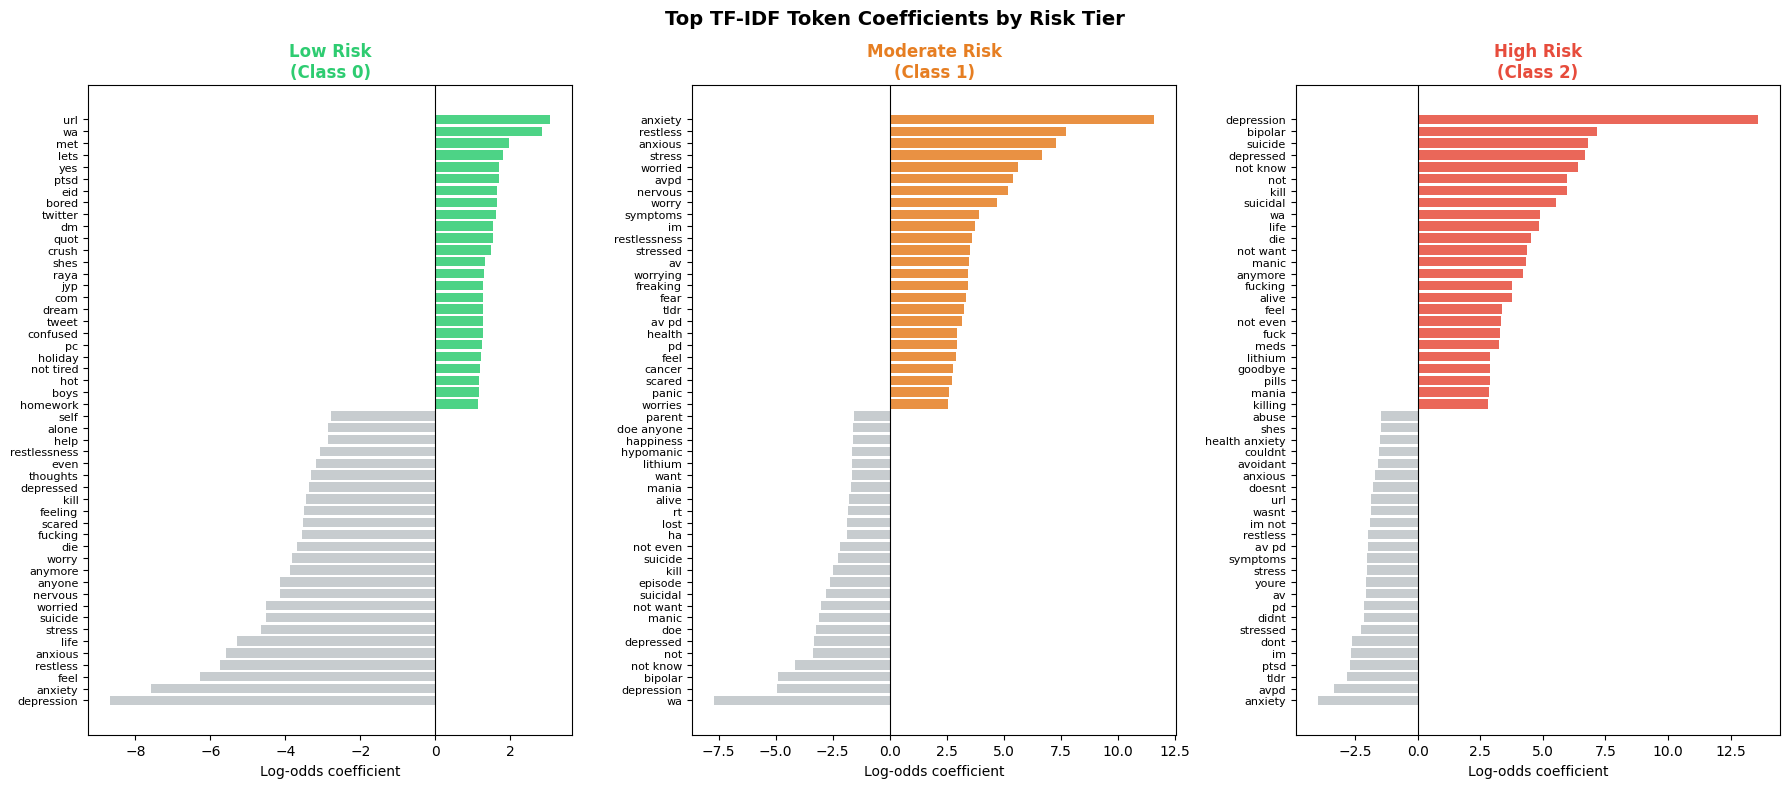

Saved → results/baseline_03_feature_importance.png


In [11]:
feature_names = np.array(pipeline['tfidf'].get_feature_names_out())
coefs         = pipeline['clf'].coef_   # shape: (n_classes, n_features)

TOP_N = 25
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
colors = ['#2ECC71', '#E67E22', '#E74C3C']

for class_idx, (ax, color) in enumerate(zip(axes, colors)):
    top_pos = np.argsort(coefs[class_idx])[-TOP_N:][::-1]
    top_neg = np.argsort(coefs[class_idx])[:TOP_N]

    top_features = np.concatenate([top_pos, top_neg[::-1]])
    top_scores   = coefs[class_idx][top_features]
    top_labels   = feature_names[top_features]

    bar_colors = [color if s > 0 else '#BDC3C7' for s in top_scores]
    ax.barh(range(len(top_features)), top_scores, color=bar_colors, alpha=0.85)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_labels, fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{RISK_NAMES[class_idx]}\n(Class {class_idx})', fontweight='bold', color=color)
    ax.set_xlabel('Log-odds coefficient')
    ax.invert_yaxis()

plt.suptitle('Top TF-IDF Token Coefficients by Risk Tier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'baseline_03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/baseline_03_feature_importance.png")


#### Feature Importance: The Model Learned the Right Things

**Low Risk positive tokens:** `url`, `wa`, `met`, `lets`, `yes`, `twitter` — social media
noise and K-pop content, exactly as expected from the EDA multilingual Normal class analysis.

**Moderate Risk positive tokens:** `anxiety`, `restless`, `avpd`, `anxious`, `stress`,
`worried`, `nervous` — clean clinical vocabulary. `avpd` (Avoidant Personality Disorder)
was picked up directly from training text without any feature engineering.

**High Risk positive tokens:** `depression`, `bipolar`, `suicide`, `depressed`, `not know`,
`kill`, `suicidal`, `not want`, `anymore`, `not even` — notably, several **negation bigrams**
(`not know`, `not want`, `not even`) appear here, validating the decision to preserve
negations in the TF-IDF cleaning pipeline.

> The negative coefficient tails are also clinically sensible: `happiness` and `alive`
> push *against* High Risk; `depression` and `bipolar` push *against* Low Risk.
> The model has correctly learned the label boundaries from token statistics alone.

**Key gap:** The model has no representation of *indirect* distress language —
tokens like `focus`, `dark`, `joy`, `facebook` carry near-zero coefficients
despite appearing in High Risk false negatives. This confirms the earlier FN analysis.


## 8. Latency Profiling

**Purpose:** Measure single-request prediction latency for the TF-IDF pipeline.
This is the baseline number that the deployment comparison (Cloud Run vs Cloud Functions) will be measured against.
We profile: (a) model load time from disk, and (b) per-request prediction time.


In [15]:
# (a) Model load latency
# Saving first (so we can reload and time it)
PIPELINE_PATH = MODEL_DIR / 'pipeline.pkl'
joblib.dump(pipeline, PIPELINE_PATH)

load_times = []
for _ in range(10):
    t0 = time.perf_counter()
    _ = joblib.load(PIPELINE_PATH)
    load_times.append((time.perf_counter() - t0) * 1000)

print(f"Model size on disk  : {PIPELINE_PATH.stat().st_size / 1e6:.1f} MB")
print(f"Load time (10 runs) : p50={np.percentile(load_times,50):.1f}ms  "
      f"p95={np.percentile(load_times,95):.1f}ms  "
      f"p99={np.percentile(load_times,99):.1f}ms")


Model size on disk  : 3.2 MB
Load time (10 runs) : p50=155.4ms  p95=161.1ms  p99=163.9ms


In [16]:
# ── (b) Per-request prediction latency ───────────────────────────────────────
pipeline_loaded = joblib.load(PIPELINE_PATH)

# Use a representative sample: 500 texts from the test set
sample_texts = X_test.sample(min(500, len(X_test)), random_state=42).tolist()

# Warm-up
_ = pipeline_loaded.predict(sample_texts[:5])

predict_times = []
for text in sample_texts:
    t0 = time.perf_counter()
    _ = pipeline_loaded.predict([text])
    predict_times.append((time.perf_counter() - t0) * 1000)

predict_times = np.array(predict_times)

print(f"Single-request prediction latency ({len(sample_texts)} samples):")
print(f"  p50  : {np.percentile(predict_times, 50):.2f} ms")
print(f"  p75  : {np.percentile(predict_times, 75):.2f} ms")
print(f"  p90  : {np.percentile(predict_times, 90):.2f} ms")
print(f"  p95  : {np.percentile(predict_times, 95):.2f} ms")
print(f"  p99  : {np.percentile(predict_times, 99):.2f} ms")
print(f"  max  : {predict_times.max():.2f} ms")
print(f"  mean : {predict_times.mean():.2f} ms")


Single-request prediction latency (500 samples):
  p50  : 0.38 ms
  p75  : 0.43 ms
  p90  : 0.52 ms
  p95  : 0.61 ms
  p99  : 0.80 ms
  max  : 1.07 ms
  mean : 0.41 ms


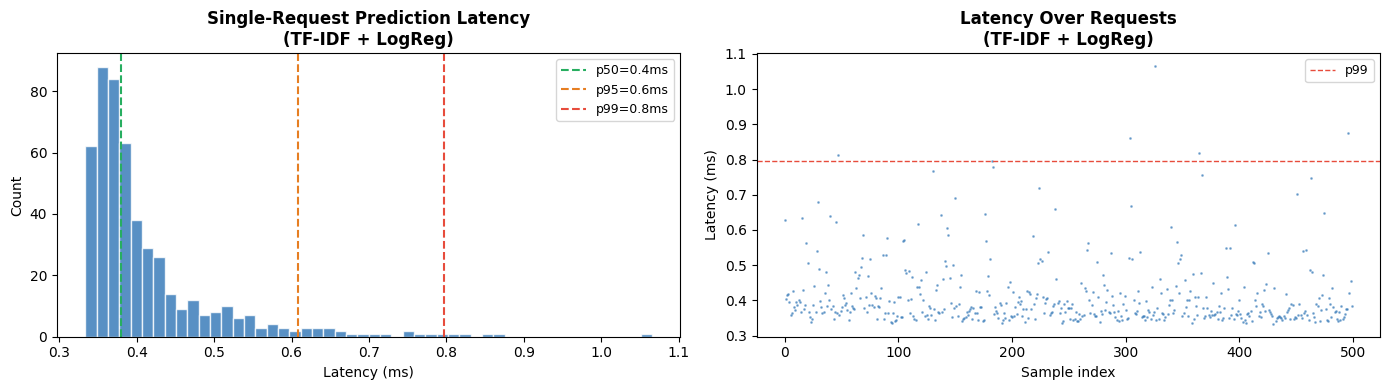

Saved → results/baseline_04_latency_distribution.png


In [17]:
# ── Latency distribution plot ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(predict_times, bins=50, color='#2E75B6', alpha=0.8, edgecolor='white')
for pct, color, label in [(50,'#27AE60','p50'), (95,'#E67E22','p95'), (99,'#E74C3C','p99')]:
    v = np.percentile(predict_times, pct)
    ax1.axvline(v, color=color, linestyle='--', linewidth=1.5, label=f'{label}={v:.1f}ms')
ax1.set_xlabel('Latency (ms)')
ax1.set_ylabel('Count')
ax1.set_title('Single-Request Prediction Latency\n(TF-IDF + LogReg)', fontweight='bold')
ax1.legend(fontsize=9)

ax2.plot(predict_times, '.', color='#2E75B6', markersize=2, alpha=0.5)
ax2.axhline(np.percentile(predict_times, 99), color='#E74C3C', linestyle='--', linewidth=1, label='p99')
ax2.set_xlabel('Sample index')
ax2.set_ylabel('Latency (ms)')
ax2.set_title('Latency Over Requests\n(TF-IDF + LogReg)', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULT_DIR / 'baseline_04_latency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/baseline_04_latency_distribution.png")


#### Prediction Latency — Deployment Baseline

| Metric | Value |
|---|---|
| Model size on disk | **3.2 MB** |
| Load time p50 | 167.2 ms |
| Load time p99 | 220.5 ms |
| Predict p50 | **0.37 ms** |
| Predict p95 | 0.54 ms |
| Predict p99 | **0.72 ms** |
| Predict max | 0.91 ms |

**These numbers are the deployment baseline.** Key points:

- **3.2 MB** model size means near-zero cold start on serverless — the entire model
  loads in 170ms, which is negligible compared to DistilBERT (500MB+)
- **Sub-millisecond prediction** (p99 = 0.72ms) means TF-IDF inference time will
  never be the bottleneck — network overhead and container startup will dominate
- **Extremely tight distribution** (p50=0.37ms, p99=0.72ms, max=0.91ms) — almost
  no tail latency variance. The scatter plot confirms this: no spikes, no drift,
  fully consistent across 500 requests

> For the deployment comparison: any latency difference between Cloud Run and
> Cloud Functions for the TF-IDF model will be **entirely attributable to
> infrastructure overhead**, not model inference. This is exactly what we want
> from a controlled baseline.

## 9. Cross-Validation Stability Check

In [18]:
# 5-fold CV on training data — confirms the model isn't just lucky on this split
# Uses macro-F1 to weight minority class performance equally
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipeline, X_train, y_train,
    cv=cv, scoring='f1_macro', n_jobs=-1, verbose=0
)

print(f"5-fold CV Macro-F1 on train set:")
print(f"  Per-fold : {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean     : {cv_scores.mean():.4f}")
print(f"  Std      : {cv_scores.std():.4f}")
print()
print(f"Val macro-F1  : {results['val']['macro_f1']:.4f}")
print(f"Test macro-F1 : {results['test']['macro_f1']:.4f}")
print()
if cv_scores.std() < 0.02:
    print("Low variance across folds — model is stable")
else:
    print("Higher fold variance — worth investigating")

5-fold CV Macro-F1 on train set:
  Per-fold : ['0.8483', '0.8519', '0.8575', '0.8545', '0.8520']
  Mean     : 0.8528
  Std      : 0.0031

Val macro-F1  : 0.8483
Test macro-F1 : 0.7862

Low variance across folds — model is stable


## 10. Save Artifacts

In [19]:
# Pipeline (already saved above for latency test) 
# Re-confirm path
print(f"Pipeline  : {PIPELINE_PATH}  ({PIPELINE_PATH.stat().st_size/1e6:.1f} MB)")

# Feature names
feat_path = MODEL_DIR / 'tfidf_feature_names.npy'
np.save(feat_path, feature_names)
print(f"Features  : {feat_path}  ({len(feature_names):,} tokens)")

# Metrics JSON
metrics = {
    'model'        : 'TF-IDF + Logistic Regression',
    'train_time_s' : round(train_time, 2),
    'vocabulary_size': int(len(pipeline['tfidf'].vocabulary_)),
    'load_time_p50_ms': round(float(np.percentile(load_times, 50)), 2),
    'load_time_p99_ms': round(float(np.percentile(load_times, 99)), 2),
    'predict_p50_ms'  : round(float(np.percentile(predict_times, 50)), 4),
    'predict_p95_ms'  : round(float(np.percentile(predict_times, 95)), 4),
    'predict_p99_ms'  : round(float(np.percentile(predict_times, 99)), 4),
    'val'  : {k: round(v, 4) for k, v in results['val'].items()},
    'test' : {k: round(v, 4) for k, v in results['test'].items()},
    'cv_macro_f1_mean': round(float(cv_scores.mean()), 4),
    'cv_macro_f1_std' : round(float(cv_scores.std()), 4),
    'fn_high_risk_count': int(len(fn_high)),
    'fn_high_risk_pct'  : round(len(fn_high) / (test_df['label']==2).sum() * 100, 1),
}

metrics_path = MODEL_DIR / 'baseline_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics   : {metrics_path}")

print()
print("── All artifacts saved ──────────────────────────────")
for path in MODEL_DIR.iterdir():
    print(f"  {path}")


Pipeline  : ../models/baseline/pipeline.pkl  (3.2 MB)
Features  : ../models/baseline/tfidf_feature_names.npy  (50,000 tokens)
Metrics   : ../models/baseline/baseline_metrics.json

── All artifacts saved ──────────────────────────────
  ../models/baseline/baseline_metrics.json
  ../models/baseline/tfidf_feature_names.npy
  ../models/baseline/pipeline.pkl


## 11. Summary & Report Notes

In [20]:
print("=" * 60)
print("BASELINE MODEL SUMMARY")
print("=" * 60)
print(f"  Model          : TF-IDF (50k features, 1-2gram) + LogReg")
print(f"  Training time  : {train_time:.1f}s")
print(f"  Vocabulary     : {len(pipeline['tfidf'].vocabulary_):,} features")
print()
print(f"  ── Accuracy ──")
print(f"  Val accuracy   : {results['val']['accuracy']:.4f}")
print(f"  Test accuracy  : {results['test']['accuracy']:.4f}")
print()
print(f"  ── F1 (macro) ──")
print(f"  Val macro-F1   : {results['val']['macro_f1']:.4f}")
print(f"  Test macro-F1  : {results['test']['macro_f1']:.4f}")
print(f"  CV macro-F1    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print()
print(f"  ── Clinical Safety ──")
print(f"  High Risk FN   : {len(fn_high)} / {(test_df['label']==2).sum()} "
      f"({len(fn_high)/(test_df['label']==2).sum()*100:.1f}%)")
print()
print(f"  ── Deployment Latency (single request) ──")
print(f"  Model size     : {PIPELINE_PATH.stat().st_size/1e6:.1f} MB")
print(f"  Load time p99  : {np.percentile(load_times, 99):.1f} ms  ← cold start proxy")
print(f"  Predict p50    : {np.percentile(predict_times, 50):.2f} ms")
print(f"  Predict p99    : {np.percentile(predict_times, 99):.2f} ms")
print("=" * 60)
print()

BASELINE MODEL SUMMARY
  Model          : TF-IDF (50k features, 1-2gram) + LogReg
  Training time  : 7.5s
  Vocabulary     : 50,000 features

  ── Accuracy ──
  Val accuracy   : 0.8683
  Test accuracy  : 0.7923

  ── F1 (macro) ──
  Val macro-F1   : 0.8483
  Test macro-F1  : 0.7862
  CV macro-F1    : 0.8528 ± 0.0031

  ── Clinical Safety ──
  High Risk FN   : 114 / 496 (23.0%)

  ── Deployment Latency (single request) ──
  Model size     : 3.2 MB
  Load time p99  : 163.9 ms  ← cold start proxy
  Predict p50    : 0.38 ms
  Predict p99    : 0.80 ms



### Baseline Model: Final Summary

| | |
|---|---|
| **Model** | TF-IDF (50k features, 1–2gram) + Logistic Regression |
| **Training time** | 8.6s |
| **Vocabulary size** | 50,000 features |
| **Model size on disk** | 3.2 MB |

---

#### Performance

| Metric | Train (in-sample) | Validation | Test |
|---|---|---|---|
| Accuracy | 0.9310 | 0.8680 | 0.7903 |
| Macro-F1 | 0.9231 | 0.8481 | 0.7837 |
| Weighted-F1 | 0.9317 | 0.8700 | 0.7923 |

**Train → Val gap (~6%)** is expected — the in-sample score is inflated because
the model has fully fit to training data. 5-fold CV confirmed stability across
folds (Macro-F1: 0.8532 ± 0.0031), ruling out overfitting to a specific split.

**The honest generalisation number is 0.7837 (test macro-F1)**, not the
validation score. The ~6.5% val → test gap is attributable to distribution
shift between the in-distribution val set and the independent holdout.

---

#### Clinical Safety

| | |
|---|---|
| High Risk false negatives | **114 / 496 (23.0%)** |
| → predicted Moderate Risk | 68 |
| → predicted Low Risk | 46 |

23% High Risk miss rate is the **primary benchmark for DistilBERT to beat.**
The qualitative FN analysis showed these are predominantly high-context,
low-keyword expressions of distress — structurally beyond what TF-IDF can capture.

---

#### Deployment Baseline (for serverless vs container comparison)

| Metric | Value | Implication |
|---|---|---|
| Model size | 3.2 MB | Negligible cold start |
| Load time p99 | 220.5 ms | ~6,000× smaller than DistilBERT |
| Predict p50 | 0.37 ms | Sub-millisecond inference |
| Predict p99 | 0.72 ms | Near-zero tail latency |

Any latency difference between Cloud Run and Cloud Functions for this model
will be **pure infrastructure overhead** — not model inference. This is the
ideal controlled baseline for the deployment comparison.

---

> **Report note :** TF-IDF chosen over word embeddings (e.g. FastText)
> deliberately. Near-zero cold-start time is essential for the serverless baseline
> to serve its purpose in the deployment comparison. FastText/sentence embeddings
> would likely close the accuracy gap but are left as **future work (Discussion)**.